# DiamondScope — Prototype ML interactif

**DiamondScope** est une startup spécialisée dans l'analyse joaillière. Sa directrice data, **Camille Arnaud**, veut un outil interne : ses équipes entrent les caractéristiques d'un diamant, et l'outil prédit son **prix** (régression) ET si le diamant appartient à une **coupe premium** (classification).

Tu es recruté·e pour construire ce prototype en 1,5 jour.

**Dataset :** Diamonds (seaborn) — 53 940 diamants, 10 variables.

```python
import seaborn as sns
df = sns.load_dataset('diamonds')
```

**Livrables attendus :**
- Ce notebook (Mission 1 : classification, Mission 2 : régression)
- Un fichier `app.py` dans un dépôt GitHub public (Mission 3 : application Streamlit, avec une page d'analyse rédigée)

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, root_mean_squared_error,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

df = sns.load_dataset('diamonds')
print(df.shape)
df.head()

(53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [48]:
def explorer_dataset(dataset):
        print(f"Start {'-'*10} Pour ce dataset, la taille est de {dataset.shape} {'-'*10}")
        print('-'*30)
        display(dataset.head(3))
        print('-'*30)
        display(dataset.tail(3))
        print('-'*30)
        print(f"Présences de valeurs 'NaN'.")
        print(f"{dataset.isna().sum()}")
        display(dataset[dataset.isna().any(axis=1)])
        print('-'*30)
        print(f"Les doublons")
        print(f"{dataset.duplicated().sum()}")
        print('-'*30)
        print(f"Les types de données")
        print(f"{dataset.dtypes}")
        print('-'*30)
        print(f"Description")
        display(dataset.describe().T)
        print("FIN"+'-'*100)

In [49]:
explorer_dataset(df)

Start ---------- Pour ce dataset, la taille est de (53940, 10) ----------
------------------------------


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31


------------------------------


,carat,cut,color,clarity,depth,table,price,x,y,z
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64


------------------------------
Présences de valeurs 'NaN'.
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


,carat,cut,color,clarity,depth,table,price,x,y,z


------------------------------
Les doublons
146
------------------------------
Les types de données
carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object
------------------------------
Description


,count,mean,std,min,25%,50%,75%,max
carat,53940.0,0.797940,0.474011,0.2,0.40,0.70,1.04,5.01
depth,53940.0,61.749405,1.432621,43.0,61.00,61.80,62.50,79.00
table,53940.0,57.457184,2.234491,43.0,56.00,57.00,59.00,95.00
price,53940.0,3932.799722,3989.439738,326.0,950.00,2401.00,5324.25,18823.00
x,53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.734526,1.142135,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80


FIN----------------------------------------------------------------------------------------------------


---
## Mission 1 : classification

**1.1** — Affiche un aperçu complet du dataset : dimensions, types, statistiques descriptives, valeurs manquantes.

In [50]:
# Dimensions


# Types


# Statistiques


# Valeurs manquantes


In [51]:
df_clean=df.drop_duplicates()

In [52]:
explorer_dataset(df_clean)

Start ---------- Pour ce dataset, la taille est de (53794, 10) ----------
------------------------------


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31


------------------------------


,carat,cut,color,clarity,depth,table,price,x,y,z
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64


------------------------------
Présences de valeurs 'NaN'.
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


,carat,cut,color,clarity,depth,table,price,x,y,z


------------------------------
Les doublons
0
------------------------------
Les types de données
carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object
------------------------------
Description


,count,mean,std,min,25%,50%,75%,max
carat,53794.0,0.797780,0.473390,0.2,0.40,0.70,1.04,5.01
depth,53794.0,61.748080,1.429909,43.0,61.00,61.80,62.50,79.00
table,53794.0,57.458109,2.233679,43.0,56.00,57.00,59.00,95.00
price,53794.0,3933.065082,3988.114460,326.0,951.00,2401.00,5326.75,18823.00
x,53794.0,5.731214,1.120695,0.0,4.71,5.70,6.54,10.74
y,53794.0,5.734653,1.141209,0.0,4.72,5.71,6.54,58.90
z,53794.0,3.538714,0.705037,0.0,2.91,3.53,4.03,31.80


FIN----------------------------------------------------------------------------------------------------


**1.2** — Étudie les corrélations entre les **variables numériques** : affiche une **heatmap sur les variables numériques uniquement** et repère la **multicolinéarité** (deux features trop corrélées entre elles → on n'en gardera qu'une).

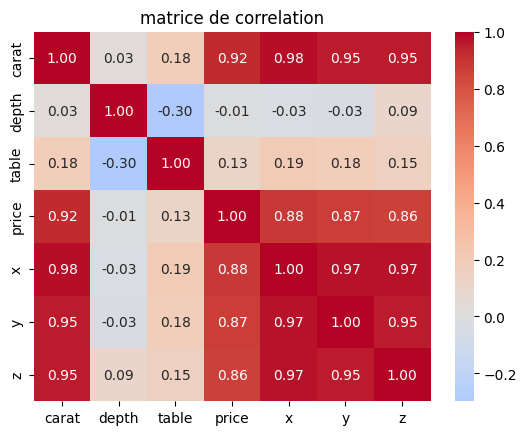

In [53]:
# Heatmap (variables numériques uniquement)
correlation=df_clean.select_dtypes(include='number').corr()

sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("matrice de correlation")
plt.show

df_clean_1=df_clean.drop(columns=['x', 'y', 'z'])

In [54]:
df_clean_1['price_log']=np.log1p(df_clean_1['price'])

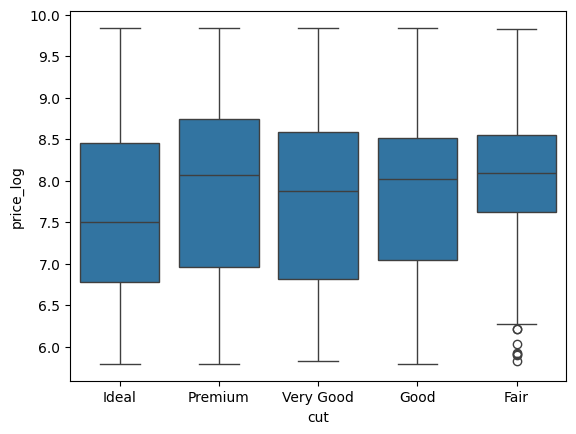

In [55]:
sns.boxplot(x=df_clean_1['cut'], y=df_clean_1['price_log'])
plt.show()

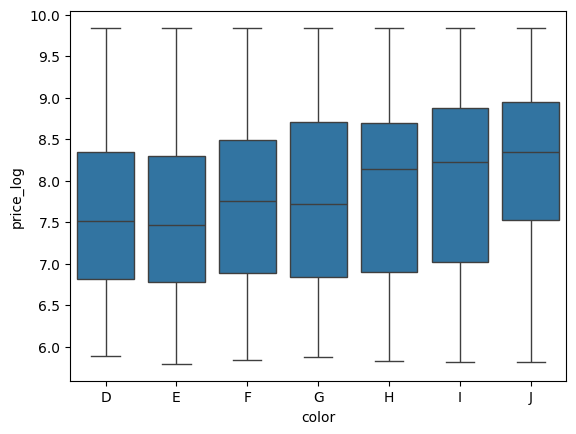

In [56]:
sns.boxplot(x=df_clean_1['color'], y=df_clean_1['price_log'])
plt.show()

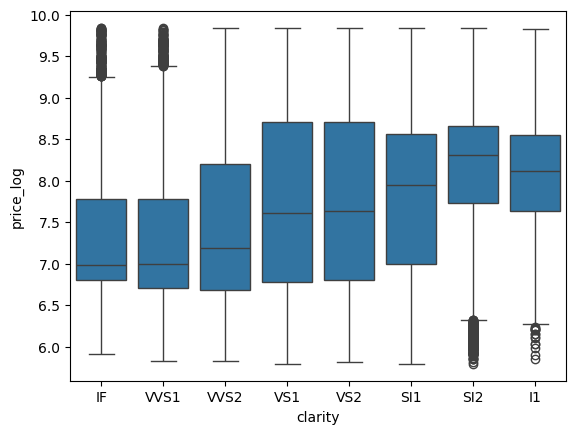

In [57]:
sns.boxplot(x=df_clean_1['clarity'], y=df_clean_1['price_log'])
plt.show()

In [58]:
df_cut_Fair=df_clean_1[df_clean_1["cut"]=="Fair"]

df_cut_Fair

,carat,cut,color,clarity,depth,table,price,price_log
8,0.22,Fair,E,VS2,65.1,61.0,337,5.823046
91,0.86,Fair,E,SI2,55.1,69.0,2757,7.922261
97,0.96,Fair,F,SI2,66.3,62.0,2759,7.922986
123,0.70,Fair,F,VS2,64.5,57.0,2762,7.924072
124,0.70,Fair,F,VS2,65.3,55.0,2762,7.924072
...,...,...,...,...,...,...,...,...
53757,0.72,Fair,F,VS2,55.4,64.0,2724,7.910224
53800,0.90,Fair,I,VS1,68.7,62.0,2732,7.913155
53863,1.00,Fair,I,SI2,66.8,56.0,2743,7.917172
53879,1.04,Fair,G,SI2,65.2,57.0,2745,7.917901


In [59]:
df_cut_Fair=df_clean_1[df_clean_1["cut"]=="Fair"]

Q1 = df_cut_Fair['price_log'].quantile(0.25)
Q3 = df_cut_Fair['price_log'].quantile(0.75)
IQR = Q3 - Q1

borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

# Option 2 : capping (remplacer par les bornes)
# df.loc[df["species"]=="Adelie"]['flipper_length_mm'] = df.loc[df["species"]=="Adelie"]['flipper_length_mm'].clip(lower=borne_basse, upper=borne_haute)

# 1. On stocke la condition dans une variable pour rendre le code plus lisible
mask_Fair = df_clean_1["cut"]=="Fair"

# 2. On utilise .loc pour cibler et modifier directement le DataFrame original
df_clean_1.loc[mask_Fair, 'price_log'] = df_clean_1.loc[mask_Fair, 'price_log'].clip(lower=borne_basse, upper=borne_haute)

**1.3** — Transforme (encodage et nettoyage) les données pour les exploiter dans un modèle de ML supervisé de **classification**.

In [60]:
# Encodage + nettoyage
df_clean_encoded=pd.get_dummies(df_clean_1, columns=['cut', 'color', 'clarity'], dtype=int)

df_clean_encoded

,carat,depth,table,price,price_log,cut_Ideal,cut_Premium,cut_Very Good,cut_Good,cut_Fair,...,color_I,color_J,clarity_IF,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
0,0.23,61.5,55.0,326,5.789960,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0.21,59.8,61.0,326,5.789960,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0.23,56.9,65.0,327,5.793014,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
3,0.29,62.4,58.0,334,5.814131,0,1,0,0,0,...,1,0,0,0,0,0,1,0,0,0
4,0.31,63.3,58.0,335,5.817111,0,0,0,1,0,...,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,2757,7.922261,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
53936,0.72,63.1,55.0,2757,7.922261,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
53937,0.70,62.8,60.0,2757,7.922261,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
53938,0.86,61.0,58.0,2757,7.922261,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0


**1.4** — Crée la colonne cible `coupe_premium` issue de `cut` pour la classification : `1` si la coupe est `Ideal` ou `Premium`, `0` sinon. Affiche la répartition.

In [61]:
# Colonne coupe_premium
df_clean_encoded["coupe_premium"] = np.where((df_clean_encoded["cut_Premium"] == 1) | (df_clean_encoded["cut_Ideal"] == 1), 1, 0)
# Répartition

df_clean_encoded["coupe_premium"].value_counts()

,count
coupe_premium,
1,35236
0,18558


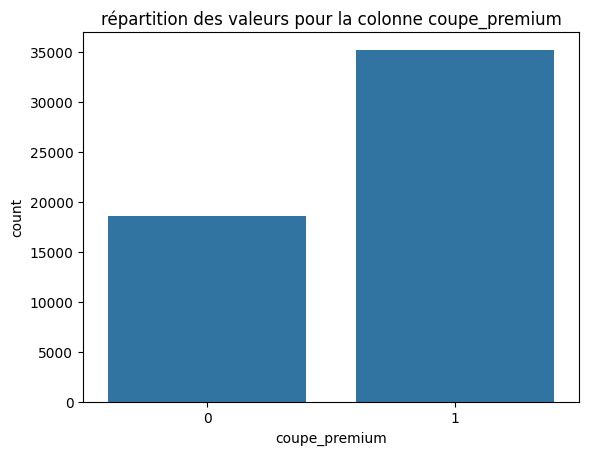

In [62]:
# Countplot
sns.countplot(data=df_clean_encoded, x="coupe_premium")
plt.title("répartition des valeurs pour la colonne coupe_premium")
plt.show()


**1.5** — Définis `X` (les features utiles pour prédire `coupe_premium`, sans multicolinéarité, sans `price` ni `cut`) et `y`.

In [63]:
X = df_clean_encoded.drop(['coupe_premium', 'cut_Ideal', 'cut_Premium', 'cut_Very Good', 'cut_Good', 'cut_Fair', 'price'], axis=1)
y = df_clean_encoded['coupe_premium']

print(f"X : {X.shape}")
print(f"y_classif (coupe_premium) : {y.shape}")

X : (53794, 19)
y_classif (coupe_premium) : (53794,)


**1.6** — Sépare ton jeu de données en entraînement / test, puis vois si d'autres transformations sont nécessaires avant d'entraîner ton `KNeighborsClassifier`. Affiche les métriques d'évaluation et interprète les résultats dans une cellule markdown.

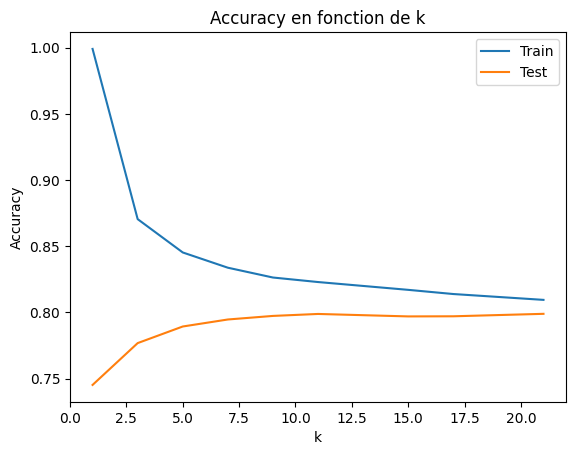

In [64]:
# À compléter (split, scaling si besoin, KNN, métriques)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

scaler=StandardScaler()

X_train_sc=scaler.fit_transform(X_train)
X_test_sc=scaler.transform(X_test)

valeurs_k = [1, 3, 5, 7, 9, 11, 15, 17, 21]
scores_train = []
scores_test  = []

for x in valeurs_k:
    model = KNeighborsClassifier(n_neighbors=x)
    model.fit(X_train_sc, y_train)
    scores_train.append(model.score(X_train_sc, y_train))
    scores_test.append(model.score(X_test_sc, y_test))

# Tracer la courbe
plt.plot(valeurs_k, scores_train, label='Train')
plt.plot(valeurs_k, scores_test, label='Test')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy en fonction de k')
plt.show()

In [65]:
# On va retenir le KNN avec K = 15

model = KNeighborsClassifier(n_neighbors=15)
model.fit(X_train_sc, y_train)

KNeighborsClassifier(n_neighbors=15)

**1.7** — Cellule d'analyse : la répartition premium vs non-premium est-elle équilibrée ? Quelle conséquence sur le choix de la métrique ?

              precision    recall  f1-score   support

           0       0.84      0.52      0.64      3739
           1       0.79      0.95      0.86      7020

    accuracy                           0.80     10759
   macro avg       0.81      0.73      0.75     10759
weighted avg       0.80      0.80      0.78     10759



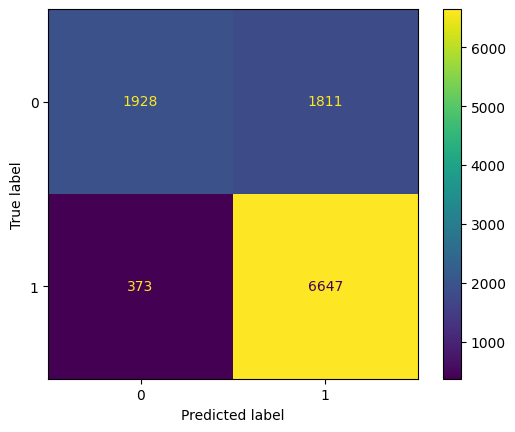

In [66]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

# La réparition est déséquibrée 66% de premium et 33% de non premium mais l'accuracy est d'environ 80% ce qui est acceptable

y_pred = model.predict(X_test_sc)
accuracy = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()

print(classification_report(y_test, y_pred))

**1.8** — Sauvegarde le modèle de classification (et le scaler).

In [67]:
# Sauvegarder
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl") 

print("Modèle classification sauvegardé.")

Modèle classification sauvegardé.


---
## Mission 2 : régression

**2.1** — Sélectionne les variables explicatives de la variable expliquée `price`. Explore quelles variables sont utiles (on ne garde pas `coupe_premium`).

In [68]:
# À compléter (X et y pour la régression)
X = df_clean_encoded.drop(['coupe_premium', 'depth', 'price_log', 'price'], axis=1)
y = df_clean_encoded['price_log']

print(f"X : {X.shape}")
print(f"y_reg_price : {y.shape}")

X : (53794, 22)
y_reg_price : (53794,)


**2.2** — Sépare le jeu de données en entraînement / test. Vois si d'autres étapes sont nécessaires avant l'entraînement.

In [69]:
# À compléter (train_test_split)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

scaler=StandardScaler()

X_train_sc=scaler.fit_transform(X_train)
X_test_sc=scaler.transform(X_test)

model=LinearRegression()
model.fit(X_train_sc, y_train)

print(f"R² train : {model.score(X_train_sc, y_train):.3f}")
print(f"R² test  : {model.score(X_test_sc,  y_test):.3f}")

R² train : 0.889
R² test  : 0.889


**2.3** — Entraîne un `LinearRegression` et affiche : R² train, R² test, MAE test, RMSE test. Analyse ces résultats dans une cellule markdown.

In [70]:
# Modèle


# Métriques


**2.4** — Identifie les 3 features qui ont le plus d'influence sur le prix (coefficients les plus élevés en valeur absolue).

In [71]:
# Coefficients


**2.5** — Sauvegarde le modèle de régression.

In [72]:
# Sauvegarder


print("Modèle régression.")

Modèle régression.


---
## Mission 3 : Application Streamlit

Dans un fichier **`app.py`** séparé (pas dans ce notebook) :

1. Affiche un titre et une courte description de l'outil.
2. Propose un site avec au minimum une page pour prédire le prix d'un diamant (widgets de saisie des variables explicatives), une page pour prédire la catégorie `coupe_premium` (widgets également), et une page répondant à la mission d'analyse (voir ci-dessous).
3. Charge les modèles sauvegardés, applique la même transformation qu'à l'entraînement, et affiche les prédictions en temps réel.
4. Affiche au moins un graphique utile (heatmap ou matrice de confusion).

Lance avec :
```bash
streamlit run app.py
```

Pousse `app.py` sur un dépôt GitHub public et soumets le lien.

### Page « Analyse » de ton application Streamlit

Dans une page de ton Streamlit, rédige 10-15 lignes à destination de Camille Arnaud qui répondent à :

1. Quelles features influencent le plus le prix d'un diamant ? (d'après ton modèle)
2. Le modèle de classification est-il fiable ? Que dit la matrice de confusion ?
3. Quelle limite vois-tu dans ce prototype ? Que faudrait-il améliorer avec plus de temps ?